<a href="https://colab.research.google.com/github/thabo-phillime/Intelligent-Power-Factor-Correction-with-IoT-Monitoring-and-Predictive-AI-control/blob/main/ml_model/Power_Factor_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving training_data.txt to training_data.txt


In [ ]:
import pandas as pd
import numpy as np

# Load file as CSV
df = pd.read_csv('training_data.txt', header=None)
df.columns = ['LoadID', 'V_adc', 'I_adc', 'Angle_tenths', 'PF_x1000', 'P_mW', 'CRC8']
# Drop the first row which contains the original header as data
df = df.iloc[1:].copy()

# Convert relevant columns to numeric, coercing errors
for col in ['LoadID', 'V_adc', 'I_adc', 'Angle_tenths', 'PF_x1000', 'P_mW']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check top rows
print(df.head())
# Check summary statistics
print(df.describe())

   LoadID  V_adc  I_adc  Angle_tenths  PF_x1000   P_mW CRC8
1       1    204    511           753       254  26477   D6
2       2     44    511           900         0      0   59
3       3      0    511           900         0      0   F4
4       4    289    511           900         0      0   C9
5       5     19    511           900         0      0   59
            LoadID        V_adc        I_adc  Angle_tenths     PF_x1000  \
count  1100.000000  1100.000000  1100.000000   1100.000000  1100.000000   
mean    550.500000   201.348182   424.281818    804.872727   131.497273   
std     317.686953   262.529835   196.153921    219.457629   275.029966   
min       1.000000     0.000000    20.000000      2.000000     0.000000   
25%     275.750000     2.000000   307.000000    836.500000     0.000000   
50%     550.500000   101.500000   471.000000    900.000000     0.000000   
75%     825.250000   216.500000   511.000000    900.000000   111.750000   
max    1100.000000  1023.000000  1003.00

In [ ]:
# Function to cap outliers
def remove_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # Cap extreme values instead of deleting
        df[col] = np.where(df[col] < lower, lower,
                           np.where(df[col] > upper, upper, df[col]))
    return df

numeric_cols = ['V_adc', 'I_adc', 'Angle_tenths', 'PF_x1000', 'P_mW']
df_clean = remove_outliers_iqr(df.copy(), numeric_cols)

In [ ]:
print("Before cleaning:")
print(df[numeric_cols].describe())

print("\nAfter cleaning:")
print(df_clean[numeric_cols].describe())


Before cleaning:
             V_adc        I_adc  Angle_tenths     PF_x1000           P_mW
count  1100.000000  1100.000000   1100.000000  1100.000000    1100.000000
mean    201.348182   424.281818    804.872727   131.497273   32226.768182
std     262.529835   196.153921    219.457629   275.029966   89375.781086
min       0.000000    20.000000      2.000000     0.000000       0.000000
25%       2.000000   307.000000    836.500000     0.000000       0.000000
50%     101.500000   471.000000    900.000000     0.000000       0.000000
75%     216.500000   511.000000    900.000000   111.750000    9914.750000
max    1023.000000  1003.000000    900.000000  1000.000000  495344.000000

After cleaning:
             V_adc        I_adc  Angle_tenths     PF_x1000          P_mW
count  1100.000000  1100.000000   1100.000000  1100.000000   1100.000000
mean    169.201818   419.468182    862.062045    66.515341   5909.355000
std     189.380767   184.376829     57.225919   100.470787   9285.501784
min     

In [ ]:
df_clean.to_csv('training_data_cleaned.txt', index=False, header=False)
from google.colab import files
files.download('training_data_cleaned.txt')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np

# --- 1️⃣ Load Data ---
# If your file is tab or space separated, use delim_whitespace=True
df = pd.read_csv("/content/training_data.txt", header=None)

# Assign all original column names first, as the file has 7 columns
all_columns = ["LoadID", "V_adc", "I_adc", "Angle_tenths", "PF_x1000", "P_mW", "CRC8"]
df.columns = all_columns

# Drop the first row which contains the original header as data
df = df.iloc[1:].copy()

# Now, select only the columns intended for this analysis
df = df[["V_adc", "I_adc", "Angle_tenths", "PF_x1000", "P_mW"]]

# Convert relevant columns to numeric, coercing errors
for col in df.columns: # Iterate over the now 5 selected columns
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Initial shape:", df.shape)
print(df.head())

# --- 2️⃣ Remove invalid or zero readings ---
df = df[(df["V_adc"] > 0) & (df["I_adc"] > 0)]
df = df[df["Angle_tenths"] <= 900]   # valid range
df = df[df["PF_x1000"].between(0, 1000)]  # ensure PF range is logical

# --- 3️⃣ Recalculate Power (optional consistency check) ---
df["P_mW"] = df["V_adc"] * df["I_adc"] * (df["PF_x1000"] / 1000.0)

# --- 4️⃣ Clamp and normalize values ---
# limit extremes for stability
df["V_adc"] = np.clip(df["V_adc"], 0, 1023)
df["I_adc"] = np.clip(df["I_adc"], 0, 1023)
df["PF_x1000"] = np.clip(df["PF_x1000"], 0, 1000)
df["Angle_tenths"] = np.clip(df["Angle_tenths"], 0, 900)

# Normalize (optional for ML)
df_norm = df.copy()
df_norm["V_adc"] /= 1023.0
df_norm["I_adc"] /= 1023.0
df_norm["PF_x1000"] /= 1000.0
df_norm["Angle_tenths"] /= 900.0
df_norm["P_mW"] /= df_norm["P_mW"].max()

# --- 5️⃣ Save cleaned and normalized data ---
df.to_csv("/content/final_cleaned_data.csv", index=False)
df_norm.to_csv("/content/final_normalized_data.csv", index=False)

# --- 6️⃣ Display summary ---
print("\nAfter cleaning:")
print(df.describe())

print("\nNormalized data sample:")
print(df_norm.head())

Initial shape: (1100, 5)
   V_adc  I_adc  Angle_tenths  PF_x1000   P_mW
1    204    511           753       254  26477
2     44    511           900         0      0
3      0    511           900         0      0
4    289    511           900         0      0
5     19    511           900         0      0

After cleaning:
             V_adc        I_adc  Angle_tenths     PF_x1000           P_mW
count   855.000000   855.000000    855.000000   855.000000     855.000000
mean    259.044444   469.425731    778.125146   168.284211   41461.578736
std     271.534891   186.592177    242.376330   302.008212   99480.492298
min       1.000000    20.000000      2.000000     0.000000       0.000000
25%      86.000000   426.000000    806.500000     0.000000       0.000000
50%     160.000000   488.000000    870.000000    52.000000     198.860000
75%     455.500000   523.000000    900.000000   163.000000   16045.938000
max    1023.000000  1003.000000    900.000000  1000.000000  495344.628000

Normalize

In [ ]:
df_clean.to_csv("training_cleaned.csv", index=False)
df_norm.to_csv("training_normalized.csv", index=False)


In [ ]:
from google.colab import files
files.download("training_normalized.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.model_selection import train_test_split

X = df_norm[["V_adc", "I_adc", "Angle_tenths", "PF_x1000"]]
y = df_norm["P_mW"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


R²: 0.988005684528424
MAE: 0.004344291244652059


In [ ]:
import joblib
joblib.dump(model, "pfc_model.pkl")
files.download("pfc_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

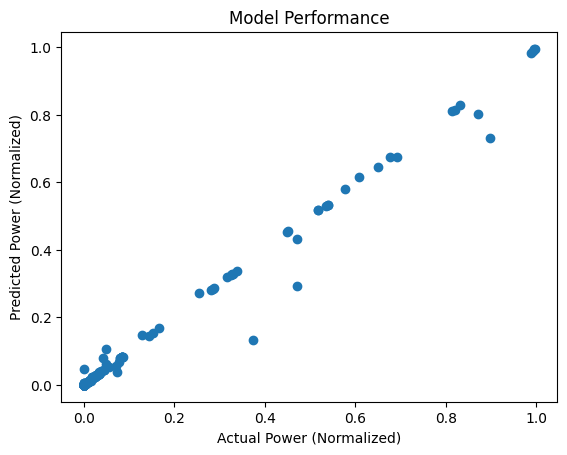

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Power (Normalized)")
plt.ylabel("Predicted Power (Normalized)")
plt.title("Model Performance")
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib


In [ ]:
# Convert PF from per-thousand to decimal
df['PF'] = df['PF_x1000'] / 1000.0

# Compute reactive power (Q_mVAR)
# tan(acos(PF)) gives the tangent of the phase angle
df['Q_mVAR'] = df['P_mW'] * np.tan(np.arccos(df['PF']))

# Inspect new column
df[['P_mW', 'PF', 'Q_mVAR']].head()

,P_mW,PF,Q_mVAR
1,26477.976,0.254,100825.236538
2,0.000,0.000,0.000000
4,0.000,0.000,0.000000
5,0.000,0.000,0.000000
6,0.000,0.000,0.000000


In [ ]:
# Features and target
X = df[['V_adc', 'I_adc', 'Angle_tenths', 'PF_x1000']]
y = df['Q_mVAR']

In [ ]:
# Create scalers
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# Fit-transform the data
X_scaled = X_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1))


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.3, random_state=42
)


In [ ]:
rf_q = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_q.fit(X_train, y_train.ravel())


RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
# Predict normalized Q
y_pred_scaled = rf_q.predict(X_test)

# Denormalize predictions and true values
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_true = y_scaler.inverse_transform(y_test.reshape(-1, 1))

# Compute metrics
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


R² Score: 0.9891
MAE: 2666.0354
RMSE: 17475.5985


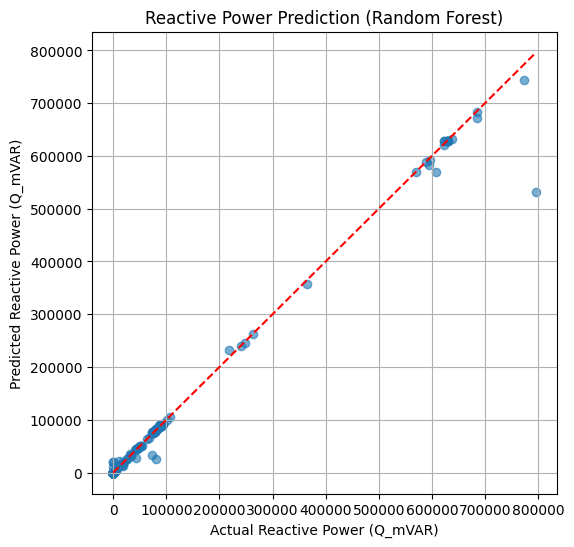

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.6)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
plt.xlabel("Actual Reactive Power (Q_mVAR)")
plt.ylabel("Predicted Reactive Power (Q_mVAR)")
plt.title("Reactive Power Prediction (Random Forest)")
plt.grid(True)
plt.show()

In [ ]:
joblib.dump(rf_q, 'rf_reactive_model.pkl')
joblib.dump(X_scaler, 'X_scaler.pkl')
joblib.dump(y_scaler, 'y_scaler.pkl')
print("✅ Model and scalers saved successfully.")


✅ Model and scalers saved successfully.


In [ ]:
y_pred_denorm = y_scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test_denorm = y_scaler.inverse_transform(y_test.reshape(-1, 1))

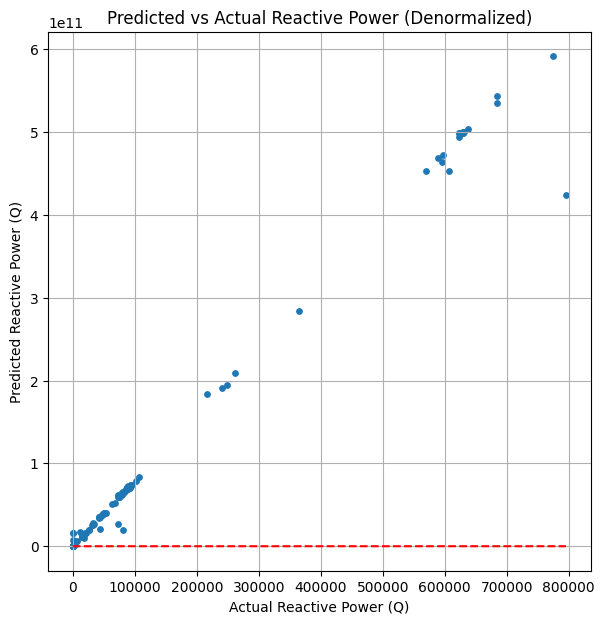

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.scatter(y_test_denorm, y_pred_denorm, s=15)
plt.plot([min(y_test_denorm), max(y_test_denorm)],
         [min(y_test_denorm), max(y_test_denorm)], 'r--')
plt.xlabel("Actual Reactive Power (Q)")
plt.ylabel("Predicted Reactive Power (Q)")
plt.title("Predicted vs Actual Reactive Power (Denormalized)")
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd

importances = model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df.sort_values(by='Importance', ascending=False, inplace=True)

print(importance_df)


        Feature  Importance
3      PF_x1000    0.643676
1         I_adc    0.222120
2  Angle_tenths    0.111066
0         V_adc    0.023138


In [ ]:
import joblib
joblib.dump(model, 'reactive_power_model.pkl')


['reactive_power_model.pkl']

In [ ]:
import joblib
joblib.dump(model, "reactive_power_model.pkl")
files.download("reactive_power_model.pkl")

NameError: name 'model' is not defined